# Node2Vec

## Learning Objectives

1. **Define** the biased 2nd-order random walk controlled by parameters $p$ and $q$
2. **Explain** how $p$ controls backtracking (DFS-like) and $q$ controls exploration (BFS/DFS balance)
3. **Derive** the transition probabilities $\alpha(t, v \to x)$ based on distance $d(t, x)$
4. **Contrast** homophily vs structural equivalence and which setting of $p, q$ captures each
5. **Implement** node2vec with alias sampling for $O(1)$ biased transitions


## Problem Statement

### DeepWalk's Limitation

DeepWalk uses **uniform random walks** — at each step, moves to a uniformly random neighbour. This biases toward **community structure** (homophily) but cannot capture **structural equivalence** (nodes with similar roles in different parts of the graph, e.g. all hubs look similar).

### Node2Vec: Controllable Walk Bias

Node2Vec introduces a **2nd-order Markov walk**: the transition probability from current node $v$ to next node $x$ depends not just on $(v, x)$ edge weight, but also on the **previous node $t$**.

The unnormalized transition weight is:
$$\alpha(t, v \to x) = w_{vx} \cdot \begin{cases} 1/q & \text{if } d(t, x) = 0 \text{ (back to }t\text{)} \\ 1 & \text{if } d(t, x) = 1 \\ 1/p & \text{if } d(t, x) = 2 \end{cases}$$

- **$p$ (return parameter):** Small $p$ → revisit $t$ often → DFS-like backtracking → explores local community
- **$q$ (in-out parameter):** Large $q$ → stay near source → BFS-like → captures local neighbourhood structure → structural equivalence


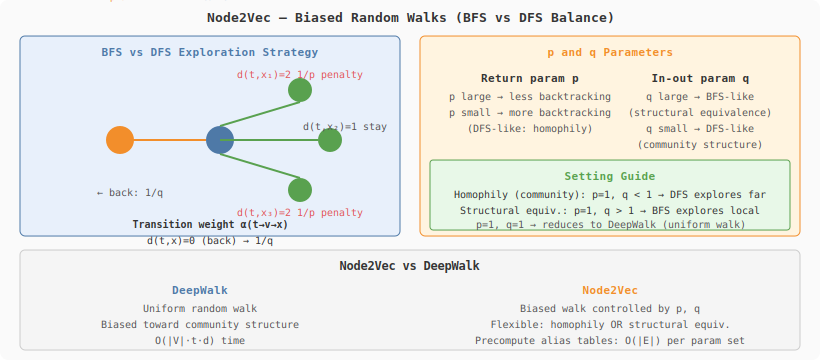

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="360" font-family="monospace" font-size="12">
  <rect width="820" height="360" fill="#fafafa" rx="8"/>
  <defs><marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#999"/></marker></defs>
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Node2Vec — Biased Random Walks (BFS vs DFS Balance)</text>

  <!-- BFS vs DFS intuition -->
  <rect x="20" y="36" width="380" height="200" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="210" y="56" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">BFS vs DFS Exploration Strategy</text>

  <!-- Source node t, current v, neighbors -->
  <circle cx="120" cy="140" r="14" fill="#f28e2b"/>
  <text x="120" cy="144" text-anchor="middle" fill="white" font-size="10">t</text>
  <text x="120" cy="164" text-anchor="middle" fill="#f28e2b" font-size="9">prev</text>

  <circle cx="220" cy="140" r="14" fill="#4e79a7"/>
  <text x="220" cy="144" text-anchor="middle" fill="white" font-size="10">v</text>
  <text x="220" cy="164" text-anchor="middle" fill="#4e79a7" font-size="9">current</text>

  <!-- neighbours of v -->
  <circle cx="300" cy="90"  r="12" fill="#59a14f"/>
  <text x="300" cy="94"  text-anchor="middle" fill="white" font-size="9">x₁</text>
  <circle cx="330" cy="140" r="12" fill="#59a14f"/>
  <text x="330" cy="144" text-anchor="middle" fill="white" font-size="9">x₂</text>
  <circle cx="300" cy="190" r="12" fill="#59a14f"/>
  <text x="300" cy="194" text-anchor="middle" fill="white" font-size="9">x₃</text>

  <line x1="120" y1="140" x2="206" y2="140" stroke="#f28e2b" stroke-width="2"/>
  <line x1="220" y1="126" x2="300" y2="102" stroke="#59a14f" stroke-width="2"/>
  <line x1="220" y1="140" x2="318" y2="140" stroke="#59a14f" stroke-width="2"/>
  <line x1="220" y1="154" x2="300" y2="178" stroke="#59a14f" stroke-width="2"/>

  <!-- distance labels -->
  <text x="300" y="78"  text-anchor="middle" fill="#e15759" font-size="10">d(t,x₁)=2  1/p penalty</text>
  <text x="345" y="130" text-anchor="middle" fill="#555" font-size="10">d(t,x₂)=1  stay</text>
  <text x="300" y="216" text-anchor="middle" fill="#e15759" font-size="10">d(t,x₃)=2  1/p penalty</text>

  <!-- back to t -->
  <text x="130" y="196" text-anchor="middle" fill="#555" font-size="10">← back: 1/q</text>

  <!-- Weight table -->
  <text x="210" y="228" text-anchor="middle" fill="#333" font-size="10" font-weight="bold">Transition weight α(t→v→x)</text>
  <text x="210" y="244" text-anchor="middle" fill="#333" font-size="10">d(t,x)=0 (back)  → 1/q</text>
  <text x="210" y="258" text-anchor="middle" fill="#333" font-size="10">d(t,x)=1 (same dist) → 1</text>
  <text x="210" y="272" text-anchor="middle" fill="#333" font-size="10">d(t,x)=2 (farther)  → 1/p</text>

  <!-- Parameter effect -->
  <rect x="420" y="36" width="380" height="200" rx="5" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="610" y="56" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">p and q Parameters</text>

  <text x="530" y="82" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">Return param p</text>
  <text x="530" y="100" text-anchor="middle" fill="#555" font-size="10">p large → less backtracking</text>
  <text x="530" y="116" text-anchor="middle" fill="#555" font-size="10">p small → more backtracking</text>
  <text x="530" y="132" text-anchor="middle" fill="#555" font-size="10">(DFS-like: homophily)</text>

  <text x="700" y="82" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">In-out param q</text>
  <text x="700" y="100" text-anchor="middle" fill="#555" font-size="10">q large → BFS-like</text>
  <text x="700" y="116" text-anchor="middle" fill="#555" font-size="10">(structural equivalence)</text>
  <text x="700" y="132" text-anchor="middle" fill="#555" font-size="10">q small → DFS-like</text>
  <text x="700" y="148" text-anchor="middle" fill="#555" font-size="10">(community structure)</text>

  <!-- Settings guide -->
  <rect x="430" y="160" width="360" height="70" rx="3" fill="#e8f8e8" stroke="#59a14f"/>
  <text x="610" y="180" text-anchor="middle" fill="#59a14f" font-size="11" font-weight="bold">Setting Guide</text>
  <text x="610" y="198" text-anchor="middle" fill="#333" font-size="10">Homophily (community): p=1, q &lt; 1 → DFS explores far</text>
  <text x="610" y="214" text-anchor="middle" fill="#333" font-size="10">Structural equiv.:     p=1, q &gt; 1 → BFS explores local</text>
  <text x="610" y="228" text-anchor="middle" fill="#555" font-size="10">p=1, q=1 → reduces to DeepWalk (uniform walk)</text>

  <!-- Bottom box -->
  <rect x="20" y="250" width="780" height="100" rx="5" fill="#f5f5f5" stroke="#ccc"/>
  <text x="410" y="270" text-anchor="middle" fill="#333" font-size="12" font-weight="bold">Node2Vec vs DeepWalk</text>
  <text x="200" y="294" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">DeepWalk</text>
  <text x="200" y="312" text-anchor="middle" fill="#555" font-size="10">Uniform random walk</text>
  <text x="200" y="328" text-anchor="middle" fill="#555" font-size="10">Biased toward community structure</text>
  <text x="200" y="344" text-anchor="middle" fill="#555" font-size="10">O(|V|·t·d) time</text>
  <text x="610" y="294" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">Node2Vec</text>
  <text x="610" y="312" text-anchor="middle" fill="#555" font-size="10">Biased walk controlled by p, q</text>
  <text x="610" y="328" text-anchor="middle" fill="#555" font-size="10">Flexible: homophily OR structural equiv.</text>
  <text x="610" y="344" text-anchor="middle" fill="#555" font-size="10">Precompute alias tables: O(|E|) per param set</text>
</svg>
'''
display(SVG(svg))


## Derivation

### 2nd-Order Walk and Distance

For walk $\ldots \to t \to v \to ?$, let $x$ be a candidate next node. The **shortest path distance** $d(t, x)$:
- $d(t, x) = 0$: $x = t$ (returning to previous)
- $d(t, x) = 1$: $x$ is a common neighbour of $t$ and $v$ (triangle)
- $d(t, x) = 2$: $x$ is not connected to $t$

The normalised transition probability:
$$P(v \to x \mid t) = \frac{\alpha(t, v \to x)}{\sum_{y \in \mathcal{N}(v)} \alpha(t, v \to y)}$$

### Interpreting $p$ and $q$

| Setting | Behaviour | Captures |
|---------|-----------|----------|
| $p=1, q<1$ | Prefers moving away (DFS) | Homophily — community structure |
| $p=1, q>1$ | Prefers staying near $t$ (BFS) | Structural equivalence |
| $p=1, q=1$ | Uniform | Same as DeepWalk |
| $p<1$ | Returns to $t$ often | Dense local neighbourhood |

### Alias Sampling for $O(1)$ Transitions

Precomputing $P(v \to x \mid t)$ for all $(t, v)$ edges takes $O(|E| \cdot \text{degree})$ time. Using **alias tables**, each draw from the precomputed distribution takes $O(1)$.

The alias method: for a distribution over $n$ items, build two arrays `prob[i]` and `alias[i]` in $O(n)$. Drawing: pick $i$ uniformly, return $i$ with probability `prob[i]` else return `alias[i]`.

### Complexity

| Step | Cost |
|------|------|
| Precompute alias tables | $O(|E|)$ per $(p,q)$ setting |
| Walk generation | $O(\gamma |V| t)$ |
| Skip-Gram training | Same as DeepWalk |


## Algorithm Steps

1. **Precompute** transition probabilities and alias tables for all $(t, v)$ directed edges
2. **Generate walks:** for each node, do $\gamma$ biased walks of length $t$
   - First step: uniform neighbour; subsequent: use alias table for $(\text{prev}, \text{curr})$
3. **Train Skip-Gram** on walk corpus (same as DeepWalk)
4. **Output** embedding matrix


In [2]:
import numpy as np
import random
from collections import defaultdict


def precompute_alias(graph, p, q):
    """
    Precompute 2nd-order transition probabilities for each (prev, curr) edge.
    Returns alias tables for O(1) sampling.
    """
    alias_edges = {}

    for v in graph:
        for t in graph[v]:  # t = previous node, v = current; walk: t → v → ?
            nbrs = list(graph[v].keys())
            unnorm = []
            for x in nbrs:
                w = graph[v][x]
                if x == t:                          # back to t
                    unnorm.append(w / q)
                elif x in graph[t]:                 # d(t, x) = 1
                    unnorm.append(w)
                else:                               # d(t, x) = 2
                    unnorm.append(w / p)
            # Build alias table
            alias_edges[(t, v)] = (nbrs, alias_table(unnorm))

    return alias_edges


def alias_table(weights):
    """
    Build alias table for weighted sampling in O(n) time.
    Returns (prob, alias) arrays.
    """
    n = len(weights)
    total = sum(weights)
    prob  = [w * n / total for w in weights]
    alias = list(range(n))
    small, large = [], []
    for i, p_ in enumerate(prob):
        (small if p_ < 1.0 else large).append(i)
    while small and large:
        s, l = small.pop(), large.pop()
        alias[s] = l
        prob[l] += prob[s] - 1.0
        (small if prob[l] < 1.0 else large).append(l)
    return prob, alias


def alias_draw(prob, alias):
    """O(1) draw from alias table."""
    i = random.randrange(len(prob))
    return i if random.random() < prob[i] else alias[i]


def node2vec_walk(graph, alias_edges, start, length, p, q):
    """Generate one biased random walk."""
    walk = [start]
    if not graph[start]:
        return walk

    # First step: uniform
    nbrs = list(graph[start].keys())
    walk.append(random.choice(nbrs))

    for _ in range(length - 2):
        curr = walk[-1]
        prev = walk[-2]
        if (prev, curr) not in alias_edges or not graph[curr]:
            break
        nbrs, (prob, alias) = alias_edges[(prev, curr)]
        idx = alias_draw(prob, alias)
        walk.append(nbrs[idx])

    return walk


def node2vec(graph, dim=32, n_walks=10, walk_length=20, window=3,
             p=1.0, q=1.0, n_iter=2, lr=0.01, seed=42):
    """
    Node2Vec: biased random walks + Skip-Gram.

    p : return parameter (1/p = weight for returning to prev node)
    q : in-out parameter (1/q = weight for exploring away)
    """
    random.seed(seed)
    rng = np.random.default_rng(seed)
    n = len(graph)
    node_list = sorted(graph.keys())
    idx = {v: i for i, v in enumerate(node_list)}

    alias_edges = precompute_alias(graph, p, q)

    # Generate walks
    walks_idx = []
    for _ in range(n_walks):
        random.shuffle(node_list)
        for v in node_list:
            w = node2vec_walk(graph, alias_edges, v, walk_length, p, q)
            walks_idx.append([idx[x] for x in w])

    # Skip-Gram (simplified SGD)
    W = rng.uniform(-0.5/dim, 0.5/dim, (n, dim))
    C = np.zeros((n, dim))

    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

    for epoch in range(n_iter):
        for walk in walks_idx:
            for i, centre in enumerate(walk):
                for j in range(max(0, i-window), min(len(walk), i+window+1)):
                    if j == i: continue
                    ctx = walk[j]
                    s = sigmoid(W[centre] @ C[ctx])
                    grad = (1-s)*lr
                    C[ctx] += grad * W[centre]
                    W[centre] += grad * C[ctx]
                    # One negative sample
                    neg = rng.integers(0, n)
                    sn = sigmoid(W[centre] @ C[neg])
                    gn = -sn*lr
                    C[neg] += gn * W[centre]
                    W[centre] += gn * C[neg]

    return W, idx


# ── Demo: compare p,q settings ─────────────────────────────────────────────
from collections import defaultdict

def build_graph(edges):
    g = defaultdict(dict)
    for u, v in edges:
        g[u][v] = 1.0
        g[v][u] = 1.0
    return dict(g)

# Two cliques (communities) + bridge
clique1 = [(i, j) for i in range(0, 5) for j in range(i+1, 5)]
clique2 = [(i, j) for i in range(5, 10) for j in range(i+1, 10)]
graph = build_graph(clique1 + clique2 + [(4, 5)])

def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b)+1e-9))

for (p_, q_, label) in [(1, 0.5, "DFS-like (q<1, homophily)"), (1, 2, "BFS-like (q>1, struct. equiv.)")]:
    emb, idx = node2vec(graph, dim=8, n_walks=15, walk_length=15, p=p_, q=q_, seed=0)
    sim_in  = np.mean([cosine_sim(emb[i], emb[j]) for i in range(0,5) for j in range(i+1,5)])
    sim_out = np.mean([cosine_sim(emb[i], emb[j]) for i in range(0,5) for j in range(5,10)])
    print(f"{label}: within={sim_in:.3f}, across={sim_out:.3f}")


DFS-like (q<1, homophily): within=0.973, across=-0.840


BFS-like (q>1, struct. equiv.): within=0.974, across=-0.850
